#1. LOAD DATA

In [2]:
!pip install datasets -q
from datasets import load_dataset

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

train = dataset["train"]
val   = dataset["validation"]
test  = dataset["test"]

train_text   = train["text"]
train_labels = train["label"]

val_text     = val["text"]
val_labels   = val["label"]

test_text    = test["text"]
test_labels  = test["label"]

label_names = train.features["label"].names
label_map = {i: name for i, name in enumerate(label_names)}

print(f"Train: {len(train_text)} tweets, {len(train_labels)} labels")
print(f"Val:   {len(val_text)} tweets, {len(val_labels)} labels")
print(f"Test:  {len(test_text)} tweets, {len(test_labels)} labels")
print(f"Label mapping: {label_map}")

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 45615 tweets, 45615 labels
Val:   2000 tweets, 2000 labels
Test:  12284 tweets, 12284 labels
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


#2. EDA

##2.1. Data description

In [3]:
from collections import Counter
import re

#Count number of tweets per label
def count_labels(labels, label_map):
    counts = Counter(labels)
    return {label_map[k]: v for k, v in sorted(counts.items())}

train_label_counts = count_labels(train_labels, label_map)
val_label_counts = count_labels(val_labels, label_map)
test_label_counts = count_labels(test_labels, label_map)

print("Label counts:")
print("Train:", train_label_counts)
print("Val:  ", val_label_counts)
print("Test: ", test_label_counts)

#Average tweet length
def avg_length(texts):
    avg_words = sum(len(t.split()) for t in texts) / len(texts)
    avg_chars = sum(len(t) for t in texts) / len(texts)
    return avg_words, avg_chars

print("\nAverage tweet length:")
for name, texts in [("Train", train_text),
                    ("Val", val_text),
                    ("Test", test_text)]:
    avg_w, avg_c = avg_length(texts)
    print(f"{name}: {avg_w:.1f} words | {avg_c:.1f} characters")

#Check for duplicate tweets
def count_duplicates(texts):
    return len(texts) - len(set(texts))

print("\nDuplicate check:")
for name, texts in [("Train", train_text),
                    ("Val", val_text),
                    ("Test", test_text)]:

    dup = count_duplicates(texts)

    print(f"{name}: {dup} duplicates out of {len(texts)} "
          f"({dup / len(texts) * 100:.2f}%)")

Label counts:
Train: {'negative': 7093, 'neutral': 20673, 'positive': 17849}
Val:   {'negative': 312, 'neutral': 869, 'positive': 819}
Test:  {'negative': 3972, 'neutral': 5937, 'positive': 2375}

Average tweet length:
Train: 19.2 words | 106.9 characters
Val: 19.4 words | 107.5 characters
Test: 14.9 words | 91.3 characters

Duplicate check:
Train: 29 duplicates out of 45615 (0.06%)
Val: 0 duplicates out of 2000 (0.00%)
Test: 0 duplicates out of 12284 (0.00%)


##2.2. Data visualization

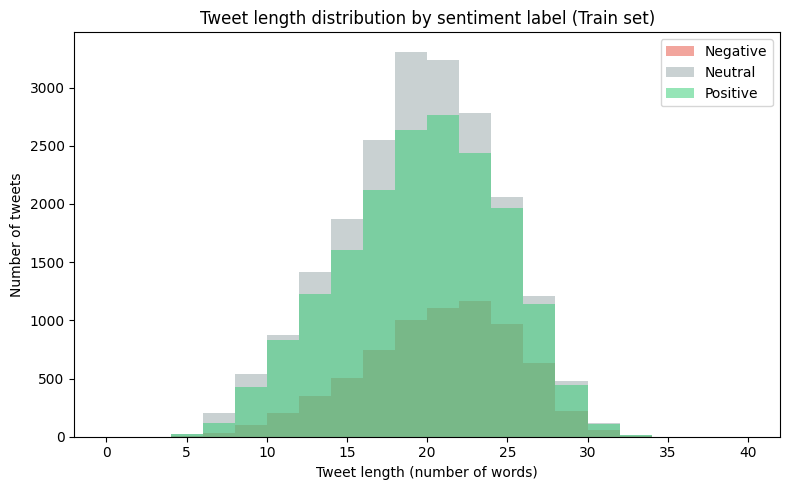

In [4]:
import matplotlib.pyplot as plt
import numpy as np

label_order = ['negative', 'neutral', 'positive']
colors = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}

#Histogram: tweet length by label (train set)
lengths_by_label = {lab: [] for lab in label_order}
for text, label in zip(train_text, train_labels):
    lengths_by_label[label_map[label]].append(len(text.split()))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(0, 41, 2)
for lab in label_order:
    ax.hist(lengths_by_label[lab], bins=bins, alpha=0.5, label=lab.capitalize(), color=colors[lab])

ax.set_xlabel('Tweet length (number of words)')
ax.set_ylabel('Number of tweets')
ax.set_title('Tweet length distribution by sentiment label (Train set)')
ax.legend()
plt.tight_layout()
plt.savefig('fig2_length_histogram.png', dpi=150)
plt.show()

#3. DATA PREPROCESSING

In [5]:
train_df = train.to_pandas()
val_df   = val.to_pandas()
test_df  = test.to_pandas()

##3.1. Preprocess for TF-IDF

In [6]:
import re
import nltk
from nltk.corpus import stopwords

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\b(rt|qt)\b', '', text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r'\d+(st|nd|rd|th)\b', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

train_df['cleaned_text'] = train_df['text'].apply(clean_tweet)
val_df['cleaned_text']   = val_df['text'].apply(clean_tweet)
test_df['cleaned_text']  = test_df['text'].apply(clean_tweet)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
for t, c in zip(train_df['text'].head(5), train_df['cleaned_text'].head(5)):
    print("Before:", t, "\nAfter:", c, "\n")

Before: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin" 
After: original draft book remus lupin survived battle hogwarts 

Before: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ" 
After: ben smith smith concussion remains lineup thursday curtis 

Before: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night. 
After: sorry bout stream last night crashed tonight sure back minecraft pc tomorrow night 

Before: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays 
After: chase headley rbi double inning david price snapped yankees streak consecutive scoreless innings blue jays 

Before: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017" 
After: alciato bee invest mil

##3.2. Preprocess for BERT/RoBERTa

In [8]:
def clean_tweet_bert(text):
    text = re.sub(r'http\S+|www\S+', 'http', text)
    text = re.sub(r'@\w+', '@user', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['cleaned_text_bert'] = train_df['text'].apply(clean_tweet_bert)
val_df['cleaned_text_bert']   = val_df['text'].apply(clean_tweet_bert)
test_df['cleaned_text_bert']  = test_df['text'].apply(clean_tweet_bert)

In [9]:
for t, c in zip(train_df['text'].head(5), train_df['cleaned_text_bert'].head(5)):
    print("Before:", t, "\nAfter:", c, "\n")

Before: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin" 
After: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin" 

Before: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ" 
After: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ" 

Before: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night. 
After: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night. 

Before: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays 
After: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against 

#4. TRAIN AND EVALUATE MODELS

##4.1. Baseline TF-IDF + SVM

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(train_df['cleaned_text'])
X_val   = vectorizer.transform(val_df['cleaned_text'])
X_test  = vectorizer.transform(test_df['cleaned_text'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC(max_iter=5000)
svm_model.fit(X_train, y_train)

val_pred = svm_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.6495
              precision    recall  f1-score   support

           0       0.59      0.45      0.51       312
           1       0.63      0.67      0.65       869
           2       0.68      0.70      0.69       819

    accuracy                           0.65      2000
   macro avg       0.63      0.61      0.62      2000
weighted avg       0.65      0.65      0.65      2000



Test Accuracy: 0.5666720937805275
              precision    recall  f1-score   support

           0       0.61      0.47      0.53      3972
           1       0.60      0.62      0.61      5937
           2       0.46      0.60      0.52      2375

    accuracy                           0.57     12284
   macro avg       0.56      0.56      0.55     12284
weighted avg       0.58      0.57      0.57     12284



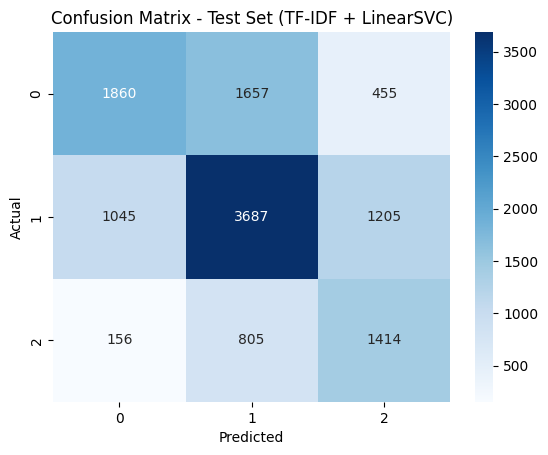

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_pred = svm_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set (TF-IDF + LinearSVC)')
plt.show()

##4.2. Fine-tune BERT

In [13]:
import os
import random
import torch
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

In [14]:
BERT_MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BERT_OUTPUT_DIR = "/content/bert_tweeteval_sentiment"


def dataframe_to_hf_dataset(df):
    d = df[["cleaned_text_bert", "label"]].copy()
    d = d.rename(columns={"cleaned_text_bert": "text"})
    return Dataset.from_pandas(d, preserve_index=False)


bert_train_dataset = dataframe_to_hf_dataset(train_df)
bert_val_dataset = dataframe_to_hf_dataset(val_df)
bert_test_dataset = dataframe_to_hf_dataset(test_df)

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=True)


def bert_tokenize_batch(batch):
    return bert_tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


bert_tokenized_train = bert_train_dataset.map(bert_tokenize_batch, batched=True, remove_columns=["text"])
bert_tokenized_val = bert_val_dataset.map(bert_tokenize_batch, batched=True, remove_columns=["text"])
bert_tokenized_test = bert_test_dataset.map(bert_tokenize_batch, batched=True, remove_columns=["text"])

bert_data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

In [15]:
label_names = train.features["label"].names  # ['negative', 'neutral', 'positive']
num_labels = len(label_names)
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
    }


bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
)

bert_training_args = TrainingArguments(
    output_dir=BERT_OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_tokenized_train,
    eval_dataset=bert_tokenized_val,
    processing_class=bert_tokenizer,
    data_collator=bert_data_collator,
    compute_metrics=compute_bert_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

bert_trainer.train()
print("Best checkpoint:", bert_trainer.state.best_model_checkpoint)
print("Best validation Macro-F1:", bert_trainer.state.best_metric)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.597145,0.597775,0.739500,0.718647,0.739975
2,0.478642,0.623900,0.747500,0.722916,0.744702
3,0.284180,0.784722,0.731500,0.712537,0.730913


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Best checkpoint: /content/bert_tweeteval_sentiment/checkpoint-5702
Best validation Macro-F1: 0.72291567033476


In [16]:
bert_val_metrics = bert_trainer.evaluate(bert_tokenized_val)
bert_test_output = bert_trainer.predict(bert_tokenized_test)
bert_y_true = bert_test_output.label_ids
bert_y_pred = np.argmax(bert_test_output.predictions, axis=-1)

bert_test_accuracy = accuracy_score(bert_y_true, bert_y_pred)
bert_test_macro_f1 = f1_score(bert_y_true, bert_y_pred, average="macro", zero_division=0)
bert_test_weighted_f1 = f1_score(bert_y_true, bert_y_pred, average="weighted", zero_division=0)

print("BERT VALIDATION RESULTS")
print(f"Accuracy    : {bert_val_metrics['eval_accuracy']:.4f}")
print(f"Macro-F1    : {bert_val_metrics['eval_f1_macro']:.4f}")
print(f"Weighted-F1 : {bert_val_metrics['eval_f1_weighted']:.4f}")
print("\nBERT TEST RESULTS")
print(f"Accuracy    : {bert_test_accuracy:.4f}")
print(f"Macro-F1    : {bert_test_macro_f1:.4f}")
print(f"Weighted-F1 : {bert_test_weighted_f1:.4f}")
print(classification_report(bert_y_true, bert_y_pred, target_names=label_names, digits=4, zero_division=0))

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.284180,0.624491,3,0.747000,0.722542,0.744232


BERT VALIDATION RESULTS
Accuracy    : 0.7470
Macro-F1    : 0.7225
Weighted-F1 : 0.7442

BERT TEST RESULTS
Accuracy    : 0.6760
Macro-F1    : 0.6717
Weighted-F1 : 0.6758
              precision    recall  f1-score   support

    negative     0.7680    0.5826    0.6626      3972
     neutral     0.6773    0.7029    0.6899      5937
    positive     0.5842    0.7651    0.6625      2375

    accuracy                         0.6760     12284
   macro avg     0.6765    0.6835    0.6717     12284
weighted avg     0.6887    0.6760    0.6758     12284



In [17]:
# Training / validation curves, to match Figure 2 in the report
log_history = bert_trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []
eval_epochs, eval_acc, eval_f1_macro, eval_f1_weighted = [], [], [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])
        eval_epochs.append(entry["epoch"])
        eval_acc.append(entry["eval_accuracy"])
        eval_f1_macro.append(entry["eval_f1_macro"])
        eval_f1_weighted.append(entry["eval_f1_weighted"])


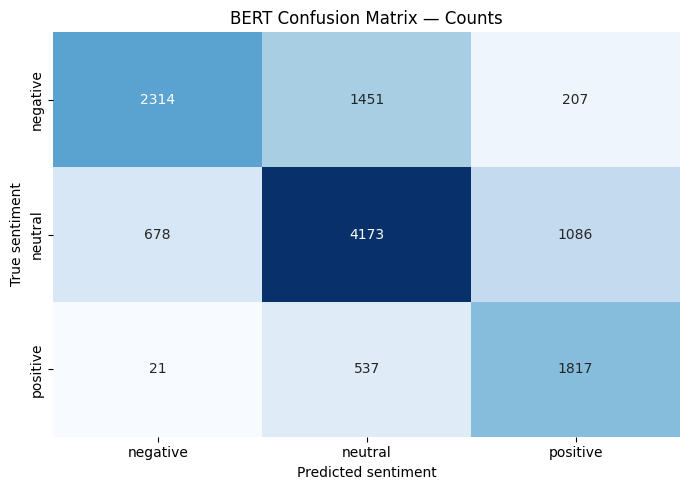

In [18]:
bert_cm = confusion_matrix(bert_y_true, bert_y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            cbar=False, ax=ax)
ax.set_xlabel('Predicted sentiment')
ax.set_ylabel('True sentiment')
ax.set_title('BERT Confusion Matrix — Counts')

plt.tight_layout()
plt.savefig("/content/cm_bert.png", dpi=200, bbox_inches="tight")
plt.show()

##4.3. Fine-tune RoBERTa

In [19]:
print('Upgrading torchao to a compatible version...')
!pip install torchao>=0.16.0 --upgrade --quiet

Upgrading torchao to a compatible version...


In [20]:
ROBERTA_MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)
roberta_model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME, num_labels=3)

train_ds = Dataset.from_pandas(train_df[['cleaned_text_bert', 'label']].rename(columns={'cleaned_text_bert': 'text'}))
val_ds   = Dataset.from_pandas(val_df[['cleaned_text_bert', 'label']].rename(columns={'cleaned_text_bert': 'text'}))
test_ds  = Dataset.from_pandas(test_df[['cleaned_text_bert', 'label']].rename(columns={'cleaned_text_bert': 'text'}))

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

In [21]:
def compute_roberta_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
    }

training_args = TrainingArguments(
    output_dir='./roberta_sentiment',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    seed=42,
    data_seed=42,
)

trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_roberta_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # thêm
)

trainer.train()

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation Macro-F1:", trainer.state.best_metric)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.592774,0.601527,0.738000,0.725464,0.739002
2,0.504040,0.600890,0.743000,0.723705,0.740271
3,0.376004,0.670829,0.740000,0.726637,0.739592


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint: ./roberta_sentiment/checkpoint-8553
Best validation Macro-F1: 0.7266368811520657


In [22]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

preds = trainer.predict(test_ds)
y_pred = preds.predictions.argmax(axis=1)
y_true = test_df['label']

roberta_test_accuracy = accuracy_score(y_true, y_pred)
roberta_test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("Test Accuracy:", roberta_test_accuracy)
print(classification_report(y_true, y_pred))

Test Accuracy: 0.7105991533702377
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      3972
           1       0.76      0.63      0.69      5937
           2       0.65      0.77      0.71      2375

    accuracy                           0.71     12284
   macro avg       0.70      0.73      0.71     12284
weighted avg       0.72      0.71      0.71     12284



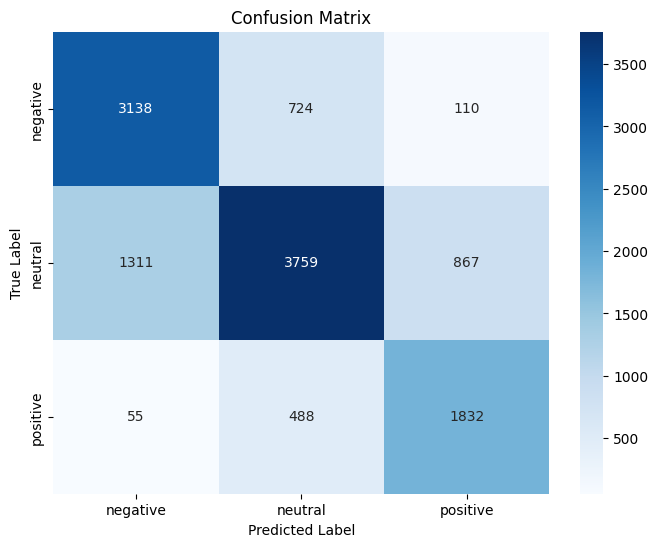

In [23]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset['train'].features['label'].names,
            yticklabels=dataset['train'].features['label'].names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

###LORA

In [24]:
!pip install peft --quiet

import time
import torch
from transformers import AutoModelForSequenceClassification

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total

def reset_gpu_stats():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_memory_gb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024**3)
    return None

In [25]:
full_trainable, full_total = count_params(roberta_model)
print(f"Full FT trainable: {full_trainable:,} / {full_total:,} ({full_trainable/full_total*100:.2f}%)")

train_time_full = None
for entry in trainer.state.log_history:
    if "train_runtime" in entry:
        train_time_full = entry["train_runtime"]

print(f"Full FT — train time (from log): {train_time_full/60:.1f} min")

peak_mem_full = get_peak_memory_gb()
print(f"Peak GPU mem: {peak_mem_full:.2f} GB")

Full FT trainable: 124,647,939 / 124,647,939 (100.00%)
Full FT — train time (from log): 21.0 min
Peak GPU mem: 3.64 GB


In [26]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_lora_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
    }

def train_lora_variant(r, alpha=16, dropout=0.1, target_modules=["query", "value"], epochs=3):
    base_model = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base", num_labels=3, id2label=id2label, label2id=label2id,
    )

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r,
        lora_alpha=alpha,
        lora_dropout=dropout,
        target_modules=target_modules,
    )
    lora_model = get_peft_model(base_model, lora_config)

    trainable, total = count_params(lora_model)
    print(f"\n=== LoRA r={r} ===")
    lora_model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"./roberta_lora_r{r}",
        learning_rate=1e-4,          # LoRA thường cần LR cao hơn full FT (2e-5)
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="linear",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=200,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        data_seed=SEED,
    )

    trainer_lora = Trainer(
        model=lora_model, args=training_args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_lora_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    reset_gpu_stats()
    start = time.time()
    trainer_lora.train()
    train_time = time.time() - start
    peak_mem = get_peak_memory_gb()

    # Evaluate trên test
    preds = trainer_lora.predict(test_ds)
    y_pred_lora = preds.predictions.argmax(axis=1)
    y_true_lora = test_df['label']

    test_acc = accuracy_score(y_true_lora, y_pred_lora)
    test_f1_macro = f1_score(y_true_lora, y_pred_lora, average="macro", zero_division=0)

    return {
        "r": r,
        "trainable_params": trainable,
        "total_params": total,
        "pct_trainable": trainable / total * 100,
        "train_time_min": train_time / 60,
        "peak_mem_gb": peak_mem,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1_macro,
        "y_pred": y_pred_lora,
        "y_true": y_true_lora,
    }

In [27]:
lora_results = []
for r in [4, 8, 16, 32]:
    result = train_lora_variant(r=r)
    lora_results.append(result)
    print(f"r={r} -> Test Acc: {result['test_accuracy']:.4f}, Macro-F1: {result['test_macro_f1']:.4f}, "
          f"Time: {result['train_time_min']:.1f} min, Mem: {result['peak_mem_gb']:.2f} GB")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



=== LoRA r=4 ===
trainable params: 740,355 || all params: 125,388,294 || trainable%: 0.5904


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.611068,0.621099,0.720500,0.701069,0.721142
2,0.602101,0.622894,0.739000,0.718599,0.736767
3,0.565881,0.605034,0.738500,0.723594,0.738819


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



=== LoRA r=32 ===
trainable params: 1,772,547 || all params: 126,420,486 || trainable%: 1.4021


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.608285,0.621643,0.717500,0.696258,0.717725
2,0.597459,0.613146,0.740000,0.721065,0.738259
3,0.563694,0.597852,0.744000,0.730333,0.744112


r=32 -> Test Acc: 0.7129, Macro-F1: 0.7129, Time: 12.3 min, Mem: 3.97 GB


In [28]:
import pandas as pd

comparison_rows = [{
    "Method": "Full fine-tune",
    "Trainable params": f"{full_trainable:,}",
    "% params": f"{full_trainable/full_total*100:.2f}%",
    "Train time (min)": f"{train_time_full/60:.1f}",
    "Peak GPU mem (GB)": f"{peak_mem_full:.2f}",
    "Test Accuracy": f"{roberta_test_accuracy:.4f}",
    "Test Macro-F1": f"{roberta_test_macro_f1:.4f}",
}]

for r in lora_results:
    comparison_rows.append({
        "Method": f"LoRA r={r['r']}",
        "Trainable params": f"{r['trainable_params']:,}",
        "% params": f"{r['pct_trainable']:.3f}%",
        "Train time (min)": f"{r['train_time_min']:.1f}",
        "Peak GPU mem (GB)": f"{r['peak_mem_gb']:.2f}",
        "Test Accuracy": f"{r['test_accuracy']:.4f}",
        "Test Macro-F1": f"{r['test_macro_f1']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv("/content/lora_vs_full_comparison.csv", index=False)

        Method Trainable params % params Train time (min) Peak GPU mem (GB) Test Accuracy Test Macro-F1
Full fine-tune      124,647,939  100.00%             21.0              3.64        0.7106        0.7122
      LoRA r=4          740,355   0.590%             14.0              3.95        0.7115        0.7119
      LoRA r=8          887,811   0.707%             13.1              3.95        0.7123        0.7124
     LoRA r=16        1,182,723   0.940%             12.4              3.96        0.7125        0.7128
     LoRA r=32        1,772,547   1.402%             12.3              3.97        0.7129        0.7129


In [29]:
import pandas as pd

def build_error_df(texts, y_true, y_pred, id2label):
    rows = []
    for index, (true_id, pred_id) in enumerate(zip(y_true, y_pred)):
        true_id, pred_id = int(true_id), int(pred_id)
        if true_id != pred_id:
            rows.append({
                "text": texts[index],
                "true_label": id2label[true_id],
                "predicted_label": id2label[pred_id],
            })
    return pd.DataFrame(rows)

best_lora = max(lora_results, key=lambda r: r["test_macro_f1"])
print(f"LoRA tốt nhất: r={best_lora['r']}")

lora_errors_df = build_error_df(
    test_ds["text"], best_lora["y_true"], best_lora["y_pred"], id2label,
)
full_errors_df = build_error_df(
    test_ds["text"], y_true, y_pred, id2label,   # y_true/y_pred của full fine-tune đã có sẵn
)

lora_only_errors = lora_errors_df.merge(
    full_errors_df[["text"]], on="text", how="left", indicator=True
)
lora_only_errors = lora_only_errors[lora_only_errors["_merge"] == "left_only"]
print(f"Tweet chỉ LoRA sai (Full FT đúng): {len(lora_only_errors)}")
display(lora_only_errors.sample(min(15, len(lora_only_errors)), random_state=SEED))

LoRA tốt nhất: r=32
Tweet chỉ LoRA sai (Full FT đúng): 804


,text,true_label,predicted_label,_merge
887,@user @user @user The answer to @user for why ...,negative,neutral,left_only
3206,What hope for Belgium after permitting it's fi...,negative,neutral,left_only
808,First Leonard Cohen and now this. 2016 can tot...,neutral,negative,left_only
2364,I need to make a t-shirt that says 'Let's disc...,neutral,positive,left_only
2433,@user - Are you sure that's not a Anti-Trump p...,negative,neutral,left_only
3481,It could all be true and @user @user Drone str...,negative,neutral,left_only
3101,"Haaretz: ""Rightists Plan mega-Jerusalem in 204...",neutral,negative,left_only
1488,Great @user need to keep a check on this Disas...,negative,positive,left_only
990,L L L #ZacEfron #Fashion 2007 Magazine photo o...,neutral,positive,left_only
2934,#humanrights #UnitedNations ♐️deporting israel...,negative,neutral,left_only


#5. ERROR ANALYSIS

In [30]:
import pandas as pd

def build_error_df(texts, y_true, y_pred, id2label):
    rows = []
    for index, (true_id, pred_id) in enumerate(zip(y_true, y_pred)):
        true_id, pred_id = int(true_id), int(pred_id)
        if true_id != pred_id:
            rows.append({
                "text": texts[index],
                "true_label": id2label[true_id],
                "predicted_label": id2label[pred_id],
            })
    return pd.DataFrame(rows)


svm_errors_df = build_error_df(
    test_df["cleaned_text_bert"].tolist(), y_test, test_pred, id2label,
)
bert_errors_df = build_error_df(
    [bert_test_dataset[i]["text"] for i in range(len(bert_test_dataset))],
    bert_y_true, bert_y_pred, id2label,
)
roberta_errors_df = build_error_df(
    test_ds["text"], y_true, y_pred, id2label,
)

print("SVM wrong predictions     :", len(svm_errors_df), "/", len(test_df))
print("BERT wrong predictions    :", len(bert_errors_df), "/", len(test_df))
print("RoBERTa wrong predictions :", len(roberta_errors_df), "/", len(test_df))

svm_errors_df.to_csv("/content/svm_prediction_errors.csv", index=False)
bert_errors_df.to_csv("/content/bert_prediction_errors.csv", index=False)
roberta_errors_df.to_csv("/content/roberta_prediction_errors.csv", index=False)

SVM wrong predictions     : 5323 / 12284
BERT wrong predictions    : 3980 / 12284
RoBERTa wrong predictions : 3555 / 12284


In [31]:
common_errors_df = (
    svm_errors_df[["text", "true_label", "predicted_label"]]
    .merge(
        bert_errors_df[["text", "true_label", "predicted_label"]],
        on=["text", "true_label"],
        suffixes=("_svm", "_bert"),
    )
    .merge(
        roberta_errors_df[["text", "true_label", "predicted_label"]]
        .rename(columns={"predicted_label": "predicted_label_roberta"}),
        on=["text", "true_label"],
    )
)

print("Number of tweets misclassified by ALL three models:", len(common_errors_df))
display(
    common_errors_df.sample(
        min(20, len(common_errors_df)),
        random_state=SEED,
    )
)
common_errors_df.to_csv("/content/common_errors_all_three_models.csv", index=False)

Number of tweets misclassified by ALL three models: 1605


,text,true_label,predicted_label_svm,predicted_label_bert,predicted_label_roberta
530,AQ operative & BRSC leader Mohamed Aldresi (Al...,negative,neutral,neutral,neutral
1174,And we're very lucky that Trump not be able to...,neutral,negative,positive,positive
168,"""As channel btwn east & west #Ukraine has huge...",neutral,positive,positive,positive
135,@user I heard Steve bannon's is so thin if he ...,negative,neutral,neutral,neutral
438,Grateful for these bad hombres,neutral,positive,positive,negative
1368,@user @user Lets start calling Lynch's office&...,negative,neutral,neutral,neutral
1305,Gaston and Belle in a New Beauty and the Beast...,neutral,positive,positive,positive
239,@user sad to say I am bradim the Tipp people w...,positive,negative,negative,negative
483,interesting how the US will now see Latin Amer...,neutral,positive,positive,positive
300,I can't even imagine how difficult the decisio...,neutral,negative,negative,negative


In [32]:
# Rule based classifier for WHY each shared error happens
# This is a heuristic built from keyword lists and regular expressions, not manually verified ground truth.
import re

SARCASM_PATTERNS = [
    "yeah right", "yeah, right", "love it when", "totally not",
    "oh great", "just what i needed", "just what i wanted",
    "can't wait to", "/s",
]
POSITIVE_WORDS = {
    "love", "great", "good", "amazing", "awesome", "happy", "best",
    "excited", "excellent", "wonderful", "nice", "glad", "fantastic",
    "perfect", "win", "yay", "congrats", "congratulations", "proud",
    "beautiful", "brilliant",
}
NEGATIVE_WORDS = {
    "hate", "bad", "worst", "terrible", "sad", "awful", "angry", "kill",
    "died", "death", "fail", "failed", "broken", "sick", "hurt", "cry",
    "crying", "sucks", "horrible", "disgusting", "annoying", "upset",
    "disappointed",
}
CONTRAST_WORDS = {"but", "however", "although", "though", "yet"}

NEGATION_PATTERN = re.compile(
    r"\b(not|never|without|cannot|can't|didn't|doesn't|won't|isn't|"
    r"aren't|wasn't|weren't|no|n't)\b",
    re.IGNORECASE,
)
NEWS_PATTERNS = [
    "reuters", "(reuters)", "(ap)", "according to", "breaking:",
    "reported", "spokesperson", "confirmed that", "in a statement",
]
SLANG_TERMS = [
    "idk", "smh", "tbh", "lmao", "lol", "omg", "btw", "fyi", "imo",
    "rn", "tbf", "ngl", "af", "fr", "ikr", "ily",
]
ELONGATION_PATTERN = re.compile(r"([a-z])\1{2,}", re.IGNORECASE)


def _word_count(text):
    clean = re.sub(r"http\S*|@user", "", text, flags=re.IGNORECASE)
    clean = re.sub(r"[^\w\s]", " ", clean)
    return len([w for w in clean.split() if w])


def detect_reasons(text):
    t = text.lower()
    reasons = []

    if any(p in t for p in SARCASM_PATTERNS):
        reasons.append("Sarcasm/irony")

    has_contrast = any(re.search(rf"\b{w}\b", t) for w in CONTRAST_WORDS)
    has_pos = any(re.search(rf"\b{w}\b", t) for w in POSITIVE_WORDS)
    has_neg = any(re.search(rf"\b{w}\b", t) for w in NEGATIVE_WORDS)
    if (has_pos and has_neg) or (has_contrast and (has_pos or has_neg)):
        reasons.append("Mixed sentiment")

    if NEGATION_PATTERN.search(t):
        reasons.append("Negation")

    if (any(p in t for p in NEWS_PATTERNS)
            or re.search(r'"[^"]{8,}"', text)
            or re.match(r"^[A-Z][A-Za-z\s]+\((AP|Reuters)\)", text)):
        reasons.append("News/quotation")

    if re.search(r"@user|http", t) or re.match(r"^(this|that|it)\b", t.strip()):
        reasons.append("Missing context")

    if (any(re.search(rf"\b{s}\b", t) for s in SLANG_TERMS)
            or ELONGATION_PATTERN.search(t)):
        reasons.append("Slang")

    if _word_count(text) <= 4:
        reasons.append("Very short")

    if not reasons:
        reasons.append("Unclear / possible label ambiguity")

    return reasons


common_errors_df["reasons"] = common_errors_df["text"].apply(detect_reasons)
common_errors_df["primary_reason"] = common_errors_df["reasons"].apply(lambda r: r[0])

category_counts = common_errors_df["primary_reason"].value_counts()
category_pcts = (category_counts / len(common_errors_df) * 100).round(1)

print(f"Cause of failure for the {len(common_errors_df)} shared errors:")
for cat in category_counts.index:
    print(f"  {cat}: {category_counts[cat]} ({category_pcts[cat]}%)")

Cause of failure for the 1605 shared errors:
  Unclear / possible label ambiguity: 674 (42.0%)
  Missing context: 541 (33.7%)
  Negation: 227 (14.1%)
  News/quotation: 80 (5.0%)
  Mixed sentiment: 41 (2.6%)
  Slang: 22 (1.4%)
  Very short: 17 (1.1%)
  Sarcasm/irony: 3 (0.2%)


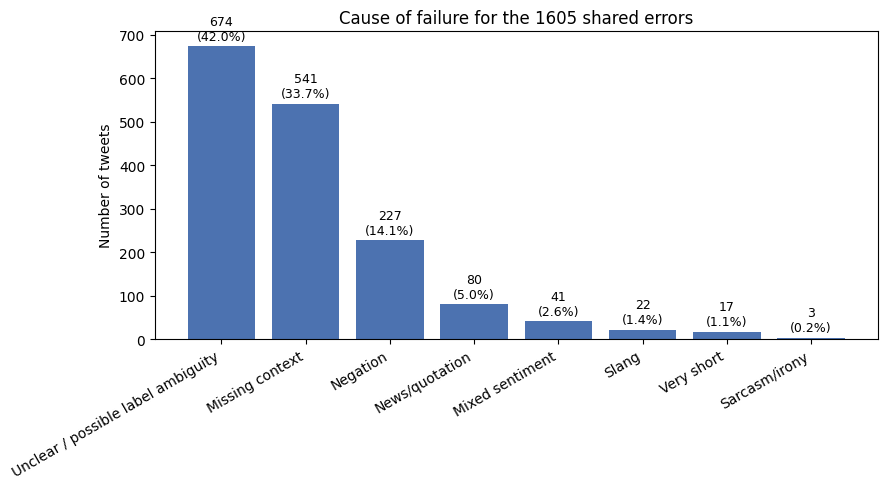

In [33]:
# Figure 4: cause of failure by category
order = category_counts.index.tolist()
counts = category_counts.values
pcts = category_pcts.values

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(order, counts, color="#4C72B0")
for b, c, p in zip(bars, counts, pcts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 8,
            f"{c}\n({p}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of tweets")
ax.set_title(f"Cause of failure for the {len(common_errors_df)} shared errors")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("/content/error_category_breakdown.png", dpi=200, bbox_inches="tight")
plt.show()

In [34]:
# Model agreement: do all three models pick the same wrong label?
common_errors_df["all_same"] = (
    (common_errors_df["predicted_label_svm"] == common_errors_df["predicted_label_bert"])
    & (common_errors_df["predicted_label_bert"] == common_errors_df["predicted_label_roberta"])
)

overall_agreement = common_errors_df["all_same"].mean() * 100
print(
    f"All three models pick the exact same wrong label in "
    f"{common_errors_df['all_same'].sum()} out of {len(common_errors_df)} "
    f"cases ({overall_agreement:.1f}%)."
)

agreement_by_cat = (
    common_errors_df.groupby("primary_reason")["all_same"].mean() * 100
).sort_values(ascending=False)
print(agreement_by_cat.round(1))

All three models pick the exact same wrong label in 1201 out of 1605 cases (74.8%).
primary_reason
Slang                                 81.8
Unclear / possible label ambiguity    77.7
Very short                            76.5
Missing context                       75.4
News/quotation                        73.8
Negation                              69.2
Sarcasm/irony                         66.7
Mixed sentiment                       48.8
Name: all_same, dtype: float64


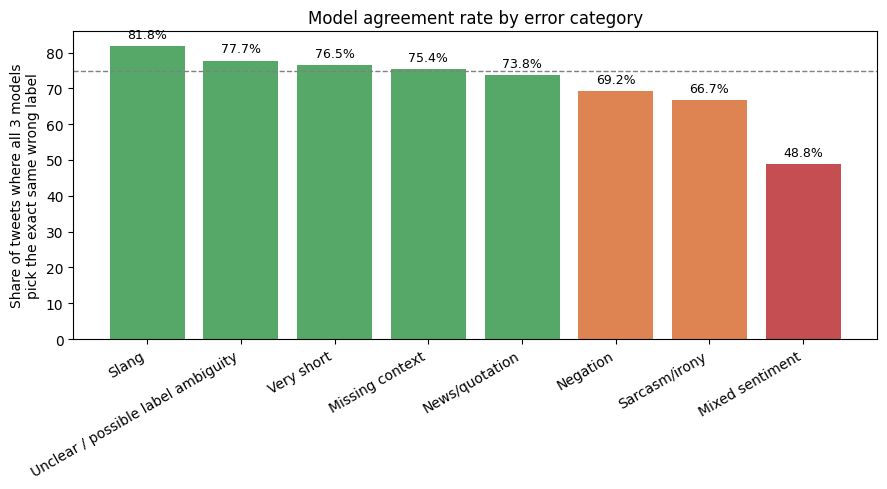

In [35]:
# Figure 5: agreement rate by category
fig, ax = plt.subplots(figsize=(9, 5))
colors = [
    "#55A868" if r >= 70 else ("#DD8452" if r >= 55 else "#C44E52")
    for r in agreement_by_cat.values
]
bars = ax.bar(agreement_by_cat.index, agreement_by_cat.values, color=colors)
for b, r in zip(bars, agreement_by_cat.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5,
            f"{r:.1f}%", ha="center", va="bottom", fontsize=9)
ax.axhline(overall_agreement, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Share of tweets where all 3 models\npick the exact same wrong label")
ax.set_title("Model agreement rate by error category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("/content/error_agreement_by_category.png", dpi=200, bbox_inches="tight")
plt.show()

In [36]:
from google.colab import files

common_errors_df.to_csv("/content/common_errors_all_three_models.csv", index=False)
files.download("/content/common_errors_all_three_models.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Export the 4 trained models to Google Drive

import os, glob, json, shutil

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

EXPORT_DIR = "/content/drive/MyDrive/tweeteval_demo"   # must match ART in the demo notebook
os.makedirs(EXPORT_DIR, exist_ok=True)

status = {}

# ---------- 1. TF-IDF vectorizer + LinearSVC ----------
# Demo loads: tfidf_vectorizer.joblib, svm_linearsvc.joblib
try:
    import joblib
    joblib.dump(vectorizer, f"{EXPORT_DIR}/tfidf_vectorizer.joblib")
    joblib.dump(svm_model,  f"{EXPORT_DIR}/svm_linearsvc.joblib")
    status["1. TF-IDF + SVM"] = "OK"
except Exception as e:
    status["1. TF-IDF + SVM"] = f"FAIL -> {e}"

# ---------- 2. BERT ----------
# Demo loads: AutoTokenizer + AutoModelForSequenceClassification from bert/
try:
    bert_trainer.save_model(f"{EXPORT_DIR}/bert")
    bert_tokenizer.save_pretrained(f"{EXPORT_DIR}/bert")
    status["2. BERT"] = "OK"
except Exception as e:
    status["2. BERT"] = f"FAIL -> {e}"

# ---------- 3. RoBERTa full fine-tune ----------
# Demo loads: AutoTokenizer + AutoModelForSequenceClassification from roberta_full/
try:
    trainer.save_model(f"{EXPORT_DIR}/roberta_full")
    tokenizer.save_pretrained(f"{EXPORT_DIR}/roberta_full")
    status["3. RoBERTa full FT"] = "OK"
except Exception as e:
    status["3. RoBERTa full FT"] = f"FAIL -> {e}"

# ---------- 4. LoRA r=32 ----------
# train_lora_variant() does not return the trainer, so the adapter is taken from disk.
# save_total_limit=1 + load_best_model_at_end=True means the remaining checkpoint IS the best one.
# Demo loads: lora_r32/adapter_config.json + lora_r32/adapter_model.safetensors
def _pick_ckpt(root):
    if not os.path.isdir(root):
        return None
    cks = glob.glob(os.path.join(root, "checkpoint-*"))
    if cks:
        return max(cks, key=lambda p: int(p.rsplit("-", 1)[-1]))
    if os.path.exists(os.path.join(root, "adapter_config.json")):
        return root
    return None

try:
    src = _pick_ckpt("/content/roberta_lora_r32") or _pick_ckpt("./roberta_lora_r32")
    if src is None:
        raise FileNotFoundError("No LoRA r=32 checkpoint found on disk")
    dst = f"{EXPORT_DIR}/lora_r32"
    if os.path.exists(dst):
        shutil.rmtree(dst)
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src):
        if f.startswith(("adapter_", "README")) or f == "config.json":
            shutil.copy2(os.path.join(src, f), os.path.join(dst, f))
    status["4. LoRA r=32"] = f"OK (from {src})"
except Exception as e:
    status["4. LoRA r=32"] = f"FAIL -> {e}"

# ---------- 5. Metadata ----------
# Demo reads meta.json for LABELS and for the metrics shown in the Metrics tab.
try:
    meta = {"label_names": list(label_names)}
    try:
        meta["metrics"] = {
            "svm":          {"accuracy": float(accuracy_score(y_test, test_pred))},
            "bert":         {"accuracy": float(bert_test_accuracy),
                             "macro_f1": float(bert_test_macro_f1)},
            "roberta_full": {"accuracy": float(roberta_test_accuracy),
                             "macro_f1": float(roberta_test_macro_f1)},
        }
        best = max(lora_results, key=lambda r: r["test_macro_f1"])
        meta["metrics"]["lora_r32"] = {
            "r": int(best["r"]),
            "accuracy": float(best["test_accuracy"]),
            "macro_f1": float(best["test_macro_f1"]),
            "trainable_params": int(best["trainable_params"]),
            "pct_trainable": float(best["pct_trainable"]),
            "train_time_min": float(best["train_time_min"]),
        }
    except Exception as inner:
        meta["metrics_note"] = f"could not collect full metrics: {inner}"
    with open(f"{EXPORT_DIR}/meta.json", "w") as fp:
        json.dump(meta, fp, indent=2)
    status["5. meta.json"] = "OK"
except Exception as e:
    status["5. meta.json"] = f"FAIL -> {e}"

# ---------- 6. CSV files for the Error Analysis tab ----------
# Demo reads common_errors_all_three_models.csv for the Shared errors tab
# and lora_vs_full_comparison.csv for the Metrics tab.
for fname in ["common_errors_all_three_models.csv", "lora_vs_full_comparison.csv"]:
    try:
        p = f"/content/{fname}"
        if os.path.exists(p):
            shutil.copy2(p, f"{EXPORT_DIR}/{fname}")
            status[f"6. {fname}"] = "OK"
        else:
            status[f"6. {fname}"] = "skipped (not found)"
    except Exception as e:
        status[f"6. {fname}"] = f"FAIL -> {e}"

print("=" * 62)
print("EXPORT RESULT ->", EXPORT_DIR)
print("=" * 62)
for k, v in status.items():
    print(f"  {k:<38} {v}")

# ---------- 7. Verify against what the demo notebook loads ----------
REQUIRED = [
    "tfidf_vectorizer.joblib",
    "svm_linearsvc.joblib",
    "bert/config.json",
    "roberta_full/config.json",
    "lora_r32/adapter_config.json",
    "lora_r32/adapter_model.safetensors",
    "meta.json",
]
OPTIONAL = [
    "common_errors_all_three_models.csv",
    "lora_vs_full_comparison.csv",
]

print("=" * 62)
print("CHECK: files the demo notebook needs")
print("=" * 62)
missing = []
for rel in REQUIRED:
    ok = os.path.exists(os.path.join(EXPORT_DIR, rel))
    print(f"  [{'OK ' if ok else 'MISS'}] {rel}")
    if not ok:
        missing.append(rel)
for rel in OPTIONAL:
    ok = os.path.exists(os.path.join(EXPORT_DIR, rel))
    print(f"  [{'OK ' if ok else '--- '}] {rel}  (optional)")

print("=" * 62)
if missing:
    print("NOT READY. Missing:", missing)
else:
    print("READY. Set ART = \"" + EXPORT_DIR + "\" in the demo notebook.")

print("\nFolder contents:")
for root, dirs, files in os.walk(EXPORT_DIR):
    lv = root.replace(EXPORT_DIR, "").count(os.sep)
    print("  " * lv + os.path.basename(root) + "/")
    for f in files:
        sz = os.path.getsize(os.path.join(root, f)) / 1e6
        print("  " * (lv + 1) + f"{f}  ({sz:.1f} MB)")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

EXPORT RESULT -> /content/drive/MyDrive/tweeteval_demo
  1. TF-IDF + SVM                        OK
  2. BERT                                OK
  3. RoBERTa full FT                     OK
  4. LoRA r=32                           OK (from /content/roberta_lora_r32/checkpoint-8553)
  5. meta.json                           OK
  6. common_errors_all_three_models.csv  OK
  6. lora_vs_full_comparison.csv         OK
CHECK: files the demo notebook needs
  [OK ] tfidf_vectorizer.joblib
  [OK ] svm_linearsvc.joblib
  [OK ] bert/config.json
  [OK ] roberta_full/config.json
  [OK ] lora_r32/adapter_config.json
  [OK ] lora_r32/adapter_model.safetensors
  [OK ] meta.json
  [OK ] common_errors_all_three_models.csv  (optional)
  [OK ] lora_vs_full_comparison.csv  (optional)
READY. Set ART = "/content/drive/MyDrive/tweeteval_demo" in the demo notebook.

Folder contents:
tweeteval_demo/
  svm_linearsvc.joblib  (0.9 MB)
  tfidf_vectorizer.joblib  (0.7 MB)
  common_errors_all_three_models.csv  (0.3 MB)
  